In [1]:
%pip install tensorboard
%pip install requests

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [2]:
# Instala/actualiza librerías necesarias para este cuaderno
%pip install -q numpy matplotlib scikit-learn pillow 
%pip install -q seaborn
%pip install -q tensorflow keras


import importlib

modules_to_check = [
    ("numpy", "np"),
    ("matplotlib", "plt"),
    ("sklearn", "sklearn"),
    ("tensorflow", "tf"),
    ("seaborn", "sns"),
]

for module_name, alias in modules_to_check:
    try:
        importlib.import_module(module_name)
        print(f"{module_name} OK")
    except ImportError:
        print(f"{module_name} NOT INSTALLED")

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
numpy OK
matplotlib OK
sklearn OK
tensorflow OK
seaborn OK


In [3]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
# Generador con data augmentation para entrenamiento
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    zoom_range=0.15,
    horizontal_flip=True,
    brightness_range=[0.8, 1.2],
    validation_split=0.2
)

# Generador para validación y evaluación, sin augmentation
val_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

In [4]:
data_dir = "./Data"

train_generator = train_datagen.flow_from_directory(
    data_dir,
    target_size=(96, 96),
    batch_size=32,
    class_mode='categorical',
    subset='training',
    shuffle=True
)

val_generator = val_datagen.flow_from_directory(
    data_dir,
    target_size=(96, 96),
    batch_size=32,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)

test_generator = val_generator

Found 47282 images belonging to 5 classes.
Found 11817 images belonging to 5 classes.


In [5]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

classes = np.unique(train_generator.classes)

class_weights_array = compute_class_weight(
    class_weight='balanced',
    classes=classes,
    y=train_generator.classes
)

class_weight = dict(zip(classes, class_weights_array))

Peso aumentado en clase 1 para que el modelo lo pueda entrenar mejor

In [6]:
class_weight[1] *= 2  #CAMBIADO

Establecemos parámetros

In [7]:
input_size = 96
num_colors = 3

learning_rate = 0.0003
# learning_rate = [0.01, 0.001, 0.0001]
epochs = 60
batch_size = 32
# bath_size = [16, 32, 64]
kernel_sizes = 5
#filters = [32, 64, 128]

Construimos la red convolucional y las redes ocultas como las de salida

In [8]:
from tensorflow import keras
def build_model():
    model = keras.models.Sequential([
        keras.layers.Input(shape=(input_size, input_size, num_colors)),

        keras.layers.Conv2D(64, 5, padding='same', activation='relu'),
        keras.layers.MaxPooling2D(2,2),
        keras.layers.Dropout(0.2),
        
        keras.layers.Conv2D(128, 5, padding='same', activation='relu'),
        keras.layers.MaxPooling2D(2,2),
        keras.layers.Dropout(0.2),

        keras.layers.Conv2D(256, 5, padding='same', activation='relu'),
        keras.layers.MaxPooling2D(2,2),
        keras.layers.Dropout(0.2),        

        keras.layers.GlobalAveragePooling2D(),#keras.layers.Flatten(), CAMBIADO
        keras.layers.Dense(256, activation='relu'),
        keras.layers.Dropout(0.3),

        keras.layers.Dense(5, activation='softmax')
    ])

    model.summary()
    return model

Monitoreo apra ver el progreso del modelo pro cada época

In [9]:
import datetime
from tensorflow.keras.callbacks import TensorBoard, EarlyStopping, ReduceLROnPlateau
log_dir = "logs/train/" + datetime.datetime.now().strftime("%Y%m%d-%H%M%S")

tensorboard_callback = TensorBoard(log_dir=log_dir)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.4,
    patience=2,
    min_lr=1e-6,
    verbose=1
)

### Comprobación de utilizar focal loss para mejorar el rendimiento de la clase 1, que es la que peor rinde

In [10]:
'''
import tensorflow as tf

def focal_loss(gamma=2., alpha=None):
    def loss(y_true, y_pred):
        y_pred = tf.clip_by_value(y_pred, 1e-7, 1 - 1e-7)
        cross_entropy = -y_true * tf.math.log(y_pred)
        weight = tf.pow(1 - y_pred, gamma)
        loss = weight * cross_entropy
        
        if alpha is not None:
            alpha_weight = y_true * alpha
            loss = alpha_weight * loss
        
        return tf.reduce_mean(tf.reduce_sum(loss, axis=1))
    return loss
    '''

'\nimport tensorflow as tf\n\ndef focal_loss(gamma=2., alpha=None):\n    def loss(y_true, y_pred):\n        y_pred = tf.clip_by_value(y_pred, 1e-7, 1 - 1e-7)\n        cross_entropy = -y_true * tf.math.log(y_pred)\n        weight = tf.pow(1 - y_pred, gamma)\n        loss = weight * cross_entropy\n\n        if alpha is not None:\n            alpha_weight = y_true * alpha\n            loss = alpha_weight * loss\n\n        return tf.reduce_mean(tf.reduce_sum(loss, axis=1))\n    return loss\n    '

Proceso de entrenamiento

In [ ]:
import tensorflow as tf
print("GPUs disponibles:", tf.config.list_physical_devices('GPU'))
print("Dispositivos:", tf.config.list_physical_devices())
print(tf.__version__)

from tensorflow.keras.optimizers import Adam
print(f"\nProbando kernel={5,5}")

model = build_model()

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
    #loss='categorical_crossentropy',
    loss = tf.keras.losses.CategoricalFocalCrossentropy(), #loss=keras.losses.CategoricalCrossentropy(label_smoothing=0.1), # cambio
    metrics=['accuracy']
)

history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=epochs,
    batch_size=batch_size,
    callbacks=[tensorboard_callback, early_stop, reduce_lr],
    class_weight=class_weight
)
val_acc = max(history.history['val_accuracy'])


2.21.0

Probando kernel=(5, 5)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 96, 96, 64)     │         4,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 48, 48, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 48, 48, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 48, 48, 128)    │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 24, 24, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 24, 24, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 24, 24, 256)    │       819,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 12, 12, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 12, 12, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │         1,285 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,096,325 (4.18 MB)

 Trainable params: 1,096,325 (4.18 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/60
  14/1478 ━━━━━━━━━━━━━━━━━━━━ 37:19 2s/step - accuracy: 0.1220 - loss: 0.2911

KeyboardInterrupt: 

Muestra de matriz de consufión


Evaluando kernel=(5, 5)
370/370 ━━━━━━━━━━━━━━━━━━━━ 148s 400ms/step


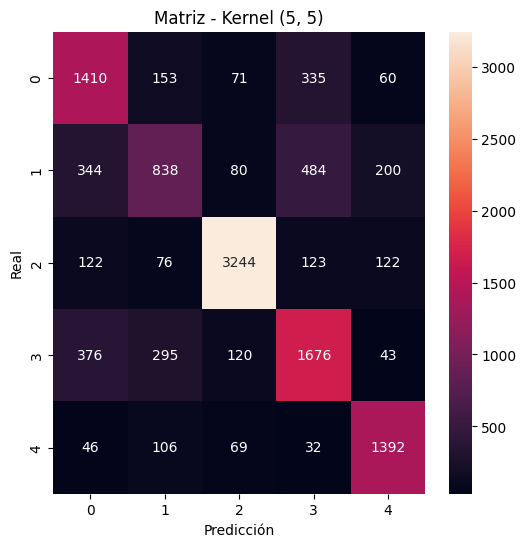

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

print(f"\nEvaluando kernel={5,5}")

test_generator.reset()
preds = model.predict(test_generator)

y_pred = np.argmax(preds, axis=1)
y_true = test_generator.classes

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,6))
sns.heatmap(cm, annot=True, fmt='d')
plt.title(f"Matriz - Kernel {5,5}")
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.show()

Verficación del mejor accuracy que el modelo ha podido llegar

In [ ]:
print(f"Kernel {5,5} → Val Accuracy: {val_acc:.4f}")

Kernel (5, 5) → Val Accuracy: 0.7244


Puede que haya una posible desbalance en el dataset, y esto explicaría porque hay uno de las clases que está rindiendo tan poco.

In [ ]:
import numpy as np

unique, counts = np.unique(train_generator.classes, return_counts=True)

for u, c in zip(unique, counts):
    print(f"Clase {u}: {c} muestras")

Clase 0: 8119 muestras
Clase 1: 7786 muestras
Clase 2: 14752 muestras
Clase 3: 10043 muestras
Clase 4: 6582 muestras


In [ ]:
print(class_weight)

{np.int32(0): np.float64(1.164724719793078), np.int32(1): np.float64(1.2145389160030824), np.int32(2): np.float64(0.6410249457700651), np.int32(3): np.float64(0.9415911580205119), np.int32(4): np.float64(1.4367061683378912)}


In [ ]:
print(preds.sum(axis=1))  # should be ~1 for each sample if softmax
x, y = next(val_generator)
print(y[:3])
tf.keras.layers.Dense(5, activation='softmax')

[0.9999999 1.        1.        ... 1.        0.9999999 1.       ]
[[1. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0.]]


<Dense name=dense_37, built=False>

No hay desbalanceo

Se manda un mensaje al programador a su telegram para que no tenga que estar atento siempre a ver cuando termina

In [ ]:
import requests

TOKEN = "8536752415:AAGnygXDRfAQEOO6yDg78Ia3d_XuhzK9MHg"
CHAT_ID = "8788334375"

def send(msg):
    url = f"https://api.telegram.org/bot{TOKEN}/sendMessage"
    requests.post(url, data={"chat_id": CHAT_ID, "text": msg})

# Ejemplo
print("Ejecutando tarea...")

import time
time.sleep(5)

send("✔ Tu ejecución en WSL ha terminado")

Resultados del modelo pasándolo a telegram

In [ ]:
#Se almacena la imagen de la matriz de la confusión
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='magma')
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.title("Matriz de Confusión")

plt.savefig("confusion_matrix.png")
plt.close()

In [ ]:
# Enviar la imagen a Telegram
def send_image(path):
    url = f"https://api.telegram.org/bot{TOKEN}/sendPhoto"
    with open(path, "rb") as img:
        requests.post(url, files={"photo": img}, data={"chat_id": CHAT_ID})

send_image("confusion_matrix.png")

In [ ]:
#Resultado del accuracy final
loss, acc = model.evaluate(val_generator)

send_message(f"✔ Entrenamiento terminado\nAccuracy: {acc:.4f}")